/Users/a46668993/.pyenv/versions/qer_env/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


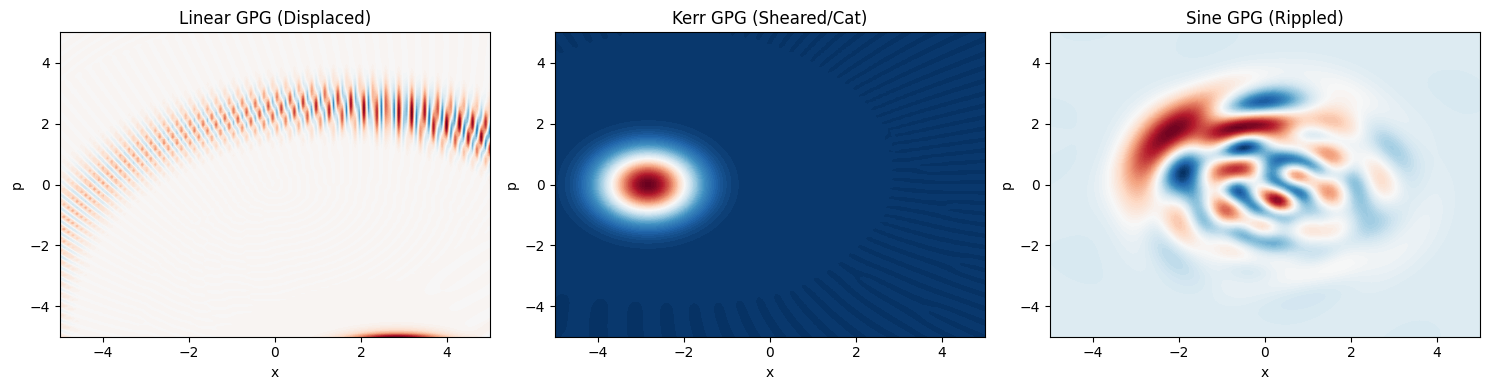

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

#parameters
N = 100 # number of spin-1/2s
alpha = 2.0 # coherent state parameter
T = 2*np.pi # total time for one period

# operators
a = destroy(N) #annihilation operator
n = a.dag() * a #number operator
x = (a + a.dag()) / np.sqrt(2) #position operator
p = 1j* (a.dag() - a) / np.sqrt(2) #momentum operator

#initial state: coherent state |alpha> 
psi0 = coherent(N, alpha)
#1. Hamiltonian (linear GPG): H = epsilon* (a.dag() e^{-i*delta*t} + hc) 
epsilon = 1.0
#delta = 1.0 
H_lin = epsilon * (a + a.dag())
#Evolve 
tlist = np.linspace(0, T, 200)
result_lin = mesolve(H_lin, psi0, tlist, [], []) 

#2. Hamiltonnian (nonlinear GPG): H = chi * (a.dag*a)^2
chi = 0.5
H_kerr = chi * n * n 
#Evolve
result_kerr = mesolve(H_kerr, psi0, tlist, [], [])

#3. Hamiltonian (non-linear) H = Omega*sin(theta*n + beta)
omega = 5.0
theta = 0.5
beta = 0.0 
sin_n = (theta*n + beta).sinm()
H_sin = omega * sin_n
#Evolve
result_sine = mesolve(H_sin, psi0, tlist, [], [])

#visualization
def plot_wigner(rho, title): 
    xvec = np.linspace(-5, 5, 100)
    W = wigner(rho, xvec, xvec)
    plt.contourf(xvec, xvec, W, 100, cmap='RdBu_r')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('p')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Plot Final States
plt.sca(axes[0])
plot_wigner(result_lin.states[-1], "Linear GPG (Displaced)")
# Note: It stays a circle, just moves location.

plt.sca(axes[1])
plot_wigner(result_kerr.states[-1], "Kerr GPG (Sheared/Cat)")
# Note: The circle smears into a crescent.

plt.sca(axes[2])
plot_wigner(result_sine.states[-1], "Sine GPG (Rippled)")
# Note: Complex non-linear distortion.

plt.tight_layout()
plt.show()


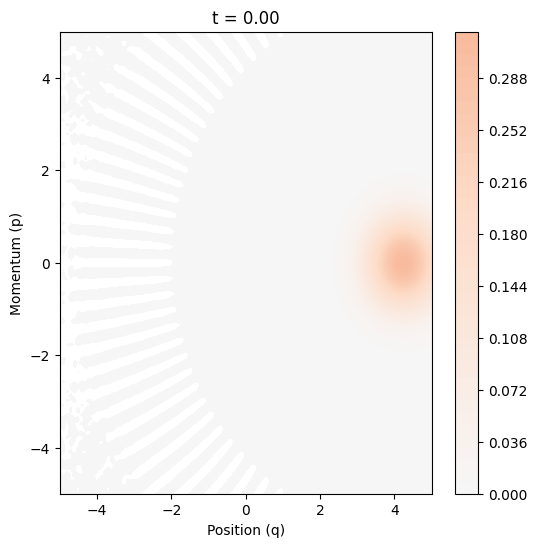

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from qutip import *
from IPython.display import HTML

# --- Parameters ---
N_dim = 60           # Increased Hilbert space to capture the spreading
alpha_0 = 3.0        # Amplitude of coherent state
chi = 1.0            # Non-linearity strength
T_revival = 2 * np.pi / chi # Time for full revival

# Operators
a = destroy(N_dim)
n = a.dag() * a
psi0 = coherent(N_dim, alpha_0)

# Hamiltonian: H = chi * (a^dagger a)^2
H_kerr = chi * (n * n)

# Time Evolution
# We want to capture specific moments:
# t = 0 (Start)
# t = T/4 (Cat State - 4 blobs)
# t = T/2 (Cat State - 2 blobs / Parity flip)
# t = T (Revival)
frames = 100
tlist = np.linspace(0, T_revival, frames)
result = mesolve(H_kerr, psi0, tlist, [], [])

# --- Animation Setup ---
fig, ax = plt.subplots(figsize=(6, 6))
xvec = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(xvec, xvec)

# Initial Wigner function
W0 = wigner(psi0, xvec, xvec)
# Use a diverging colormap (Red=Positive, Blue=Negative) to see quantum interference
contour = ax.contourf(X, Y, W0, 100, cmap='RdBu_r', vmin=-1, vmax=1)
# Add a colorbar
cbar = plt.colorbar(contour, ax=ax)
ax.set_xlabel('Position (q)')
ax.set_ylabel('Momentum (p)')
title = ax.set_title("t = 0.00")

def update(frame):
    # Calculate Wigner function for the current state
    rho = result.states[frame]
    W = wigner(rho, xvec, xvec)
    
    # Clear previous plot and redraw
    ax.clear()
    ax.contourf(X, Y, W, 100, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    
    # Update title with progress
    time_progress = tlist[frame] / T_revival
    if abs(time_progress - 0.5) < 0.01:
        state_desc = " (Cat State / Parity Flip)"
    elif abs(time_progress - 1.0) < 0.01:
        state_desc = " (Full Revival)"
    else:
        state_desc = ""
        
    ax.set_title(f"Kerr Evolution: t = {tlist[frame]:.2f}{state_desc}")
    ax.set_xlabel('q')
    ax.set_ylabel('p')

# Create Animation
anim = FuncAnimation(fig, update, frames=frames, interval=50)

# To save as a GIF (requires ImageMagick or Pillow)
# anim.save('kerr_cat_state.gif', writer='pillow', fps=20)

# To display in a Jupyter Notebook, use:
# HTML(anim.to_jshtml())

plt.show()